# 01. Importing Libraries

In [298]:
import os
import math
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy
import numpy as np
import pandas as pd
import scipy.stats as st
from collections import Counter
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import silhouette_score

# 02. Importing Data

In [64]:
books = pd.read_csv('../01. Data/books_combined.csv')

In [65]:
books.head()

,rank,title,author,avg_rating,num_ratings,cover_img_url,goodreads_url,source,year_published,genres,description,pages,series,isbn,publisher,language,ol_key,google_url
0,1.0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.35,10115839.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/2767052-th...,GoodReads,"First published September 14, 2008","Young Adult, Dystopia, Fiction, Fantasy, Scien...",Winning means fame and fortune. Losing means c...,"374 pages, Hardcover",The Hunger Games#1,NaN,NaN,NaN,NaN,NaN
1,2.0,Pride and Prejudice,Jane Austen,4.30,4920467.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/1885.Pride...,GoodReads,"First published January 28, 1813","Classics, Romance, Fiction, Historical Fiction...","Since its immediate success in 1813,Pride and ...","279 pages, Paperback",NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,To Kill a Mockingbird,Harper Lee,4.26,7016855.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/2657.To_Ki...,GoodReads,"First published July 11, 1960","Classics, Fiction, Historical Fiction, School,...","""Shoot all the bluejays you want, if you can h...","323 pages, Paperback",To Kill a Mockingbird#1,NaN,NaN,NaN,NaN,NaN
3,4.0,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,4.50,3868435.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/58613451-h...,GoodReads,"First published June 21, 2003","Fantasy, Fiction, Young Adult, Harry Potter, M...",It's official: the evil Lord Voldemort has ret...,"896 pages, Hardcover",Harry Potter#5,NaN,NaN,NaN,NaN,NaN
4,5.0,The Book Thief,Markus Zusak,4.39,2935583.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/19063.The_...,GoodReads,"First published September 1, 2005","Historical Fiction, Fiction, Young Adult, Clas...",Librarian's note: An alternate cover edition c...,"592 pages, Kindle Edition",NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
books.shape

(2004, 18)

# 03. Cleaning the full dataframe 

In [67]:
books['rank'].describe()

count    1004.000000
mean      508.044821
std       292.110079
min         1.000000
25%       255.750000
50%       508.500000
75%       760.250000
max      1013.000000
Name: rank, dtype: float64

In [68]:
books['rank'].isnull().sum()

np.int64(1000)

In [69]:
# making a book_id column and dropping rank
books = books.reset_index(drop=True)
books.index.name = 'book_id'

books = books.drop(columns=['rank'])

In [70]:
books.head()

,title,author,avg_rating,num_ratings,cover_img_url,goodreads_url,source,year_published,genres,description,pages,series,isbn,publisher,language,ol_key,google_url
book_id,,,,,,,,,,,,,,,,,
0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.35,10115839.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/2767052-th...,GoodReads,"First published September 14, 2008","Young Adult, Dystopia, Fiction, Fantasy, Scien...",Winning means fame and fortune. Losing means c...,"374 pages, Hardcover",The Hunger Games#1,NaN,NaN,NaN,NaN,NaN
1,Pride and Prejudice,Jane Austen,4.30,4920467.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/1885.Pride...,GoodReads,"First published January 28, 1813","Classics, Romance, Fiction, Historical Fiction...","Since its immediate success in 1813,Pride and ...","279 pages, Paperback",NaN,NaN,NaN,NaN,NaN,NaN
2,To Kill a Mockingbird,Harper Lee,4.26,7016855.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/2657.To_Ki...,GoodReads,"First published July 11, 1960","Classics, Fiction, Historical Fiction, School,...","""Shoot all the bluejays you want, if you can h...","323 pages, Paperback",To Kill a Mockingbird#1,NaN,NaN,NaN,NaN,NaN
3,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,4.50,3868435.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/58613451-h...,GoodReads,"First published June 21, 2003","Fantasy, Fiction, Young Adult, Harry Potter, M...",It's official: the evil Lord Voldemort has ret...,"896 pages, Hardcover",Harry Potter#5,NaN,NaN,NaN,NaN,NaN
4,The Book Thief,Markus Zusak,4.39,2935583.0,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/19063.The_...,GoodReads,"First published September 1, 2005","Historical Fiction, Fiction, Young Adult, Clas...",Librarian's note: An alternate cover edition c...,"592 pages, Kindle Edition",NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
books.dtypes

title                 str
author                str
avg_rating        float64
num_ratings       float64
cover_img_url         str
goodreads_url         str
source                str
year_published        str
genres                str
description           str
pages                 str
series                str
isbn                  str
publisher             str
language              str
ol_key                str
google_url            str
dtype: object

In [72]:
# converting num_rating into int
books['num_ratings'] = books['num_ratings'].astype('Int64')

In [73]:
books.dtypes

title                 str
author                str
avg_rating        float64
num_ratings         Int64
cover_img_url         str
goodreads_url         str
source                str
year_published        str
genres                str
description           str
pages                 str
series                str
isbn                  str
publisher             str
language              str
ol_key                str
google_url            str
dtype: object

In [74]:
# checking for patterns in year_published column
books['year_published'].unique()

<ArrowStringArray>
['First published September 14, 2008',   'First published January 28, 1813',
      'First published July 11, 1960',      'First published June 21, 2003',
  'First published September 1, 2005',    'First published October 5, 2005',
    'First published August 17, 1945',    'First published January 1, 1954',
    'First published January 1, 1956',   'First published January 10, 2012',
 ...
                             '1200.0',                             '1788.0',
                             '1817.0',                             '1916.0',
                             '1874.0',                             '1835.0',
                             '1933.0',                             '1896.0',
                             '1934.0',                             '1829.0']
Length: 1054, dtype: str

In [75]:
# cleaning the year_published column
books['year_published'] = books['year_published'].str.extract(r'(\d{4})')

In [76]:
books['year_published'].unique()

<ArrowStringArray>
['2008', '1813', '1960', '2003', '2005', '1945', '1954', '1956', '2012',
 '1890',
 ...
 '1743', '1786', '1867', '1467', '1200', '1788', '1835', '1933', '1896',
 '1829']
Length: 245, dtype: str

In [77]:
books['year_published'].dtype

<StringDtype(na_value=nan)>

In [78]:
# changing it to number and checking it
books['year_published'] = pd.to_numeric(books['year_published'], errors='coerce').astype('Int64')
books['year_published'].dtype

Int64Dtype()

In [79]:
# checking for patterns in pages column
books['pages'].unique()

<ArrowStringArray>
[             '374 pages, Hardcover',              '279 pages, Paperback',
              '323 pages, Paperback',              '896 pages, Hardcover',
         '592 pages, Kindle Edition',              '498 pages, Paperback',
  '141 pages, Mass Market Paperback', '1728 pages, Mass Market Paperback',
              '767 pages, Paperback',              '313 pages, Hardcover',
 ...
                             '684.0',                             '736.0',
                             '770.0',                             '380.0',
                             '590.0',                             '884.0',
                             '958.0',                             '874.0',
                             '749.0',                            '1856.0']
Length: 1189, dtype: str

In [80]:
# cleaning the pages column
books['pages'] = books['pages'].str.extract(r'(\d+)')

In [81]:
books['pages'].unique()

<ArrowStringArray>
[ '374',  '279',  '323',  '896',  '592',  '498',  '141', '1728',  '767',
  '313',
 ...
  '177',  '902', '1232',  '575',  '770',  '884',  '958',  '874',  '749',
 '1856']
Length: 669, dtype: str

In [82]:
books['pages'].dtype

<StringDtype(na_value=nan)>

In [83]:
# changing it to number and checking it
books['pages'] = pd.to_numeric(books['pages'], errors='coerce').astype('Int64')
books['pages'].dtype

Int64Dtype()

Manual imputation for some important data

In [84]:
# checking columns that will need manual imputation 
books.isnull().sum()

title                0
author               1
avg_rating         755
num_ratings        733
cover_img_url        4
goodreads_url     1000
source               0
year_published      20
genres               7
description          0
pages               24
series            1529
isbn              1008
publisher         1009
language          1004
ol_key            1004
google_url        1017
dtype: int64

In [85]:
# checking the rows with null to be able to search and manually fill them
books[books['year_published'].isnull()]

,title,author,avg_rating,num_ratings,cover_img_url,goodreads_url,source,year_published,genres,description,pages,series,isbn,publisher,language,ol_key,google_url
book_id,,,,,,,,,,,,,,,,,
48,Harry Potter and the Deathly Hallows (Harry Po...,J.K. Rowling,4.62,4177757,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/136251.Har...,GoodReads,<NA>,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
50,The Odyssey,Homer,3.84,1224393,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/1381.The_O...,GoodReads,<NA>,"Classics, Fiction, Poetry, Mythology, Fantasy,...","Sing to me of the man, Muse, the man of twists...",541,NaN,NaN,NaN,NaN,NaN,NaN
72,The Adventures of Sherlock Holmes (Sherlock Ho...,Arthur Conan Doyle,4.30,330762,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/3590.The_A...,GoodReads,<NA>,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
90,Gone Girl,Gillian Flynn,4.15,3508073,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/19288043-g...,GoodReads,<NA>,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
152,"The Last Thing He Told Me (Hannah Hall, #1)",Laura Dave,3.83,1187142,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/54981009-t...,GoodReads,<NA>,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
275,Beloved,Toni Morrison,3.99,503338,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/6149.Beloved,GoodReads,<NA>,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
291,The Iliad / The Odyssey,Homer,4.07,85200,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/1375.The_I...,GoodReads,<NA>,"Classics, Fiction, Poetry, Mythology, Fantasy,...",Gripping listeners and readers for more than 2...,1556,NaN,NaN,NaN,NaN,NaN,NaN
470,Tao Te Ching,Lao Tzu,4.29,185834,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/67896.Tao_...,GoodReads,<NA>,"Philosophy, Nonfiction, Classics, Spirituality...",A lucid translation of the well-known Taoist c...,107,SUNY series in Chinese Philosophy and Culture,NaN,NaN,NaN,NaN,NaN
476,القرآن الكريم,الله,4.38,73505,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/646462._,GoodReads,<NA>,"Religion, Islam, Nonfiction, Classics, Philoso...",The Quran (English pronunciation: /kɔrˈɑːn/; A...,604,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
# changing year_published to object to be able to fill the null values with the BC values
books['year_published'] = books['year_published'].astype('object')

In [87]:
# substituteing the null values with the year of the first edition of the book
# AC
books.loc[48, 'year_published'] = 2007 
books.loc[72, 'year_published'] = 1892 
books.loc[90, 'year_published'] = 2012   
books.loc[152, 'year_published'] = 2021  
books.loc[275, 'year_published'] = 1987  
books.loc[518, 'year_published'] = 2022  
books.loc[563, 'year_published'] = 2003  
books.loc[476, 'year_published'] = 632   
books.loc[866, 'year_published'] = 180   
books.loc[1710, 'year_published'] = 1897

# BC
books.loc[50, 'year_published'] = '800 BC'    
books.loc[291, 'year_published'] = '800 BC'   
books.loc[470, 'year_published'] = '400 BC'   
books.loc[585, 'year_published'] = '375 BC'   
books.loc[685, 'year_published'] = '500 BC'   
books.loc[727, 'year_published'] = '800 BC'  
books.loc[768, 'year_published'] = '800 BC'   
books.loc[795, 'year_published'] = '429 BC'   
books.loc[880, 'year_published'] = '19 BC'    
books.loc[928, 'year_published'] = '441 BC'   

In [88]:
# checking rows with null values in genres column
books[books['genres'].isnull()]

,title,author,avg_rating,num_ratings,cover_img_url,goodreads_url,source,year_published,genres,description,pages,series,isbn,publisher,language,ol_key,google_url
book_id,,,,,,,,,,,,,,,,,
48,Harry Potter and the Deathly Hallows (Harry Po...,J.K. Rowling,4.62,4177757,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/136251.Har...,GoodReads,2007,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
72,The Adventures of Sherlock Holmes (Sherlock Ho...,Arthur Conan Doyle,4.30,330762,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/3590.The_A...,GoodReads,1892,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
90,Gone Girl,Gillian Flynn,4.15,3508073,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/19288043-g...,GoodReads,2012,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
152,"The Last Thing He Told Me (Hannah Hall, #1)",Laura Dave,3.83,1187142,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/54981009-t...,GoodReads,2021,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
275,Beloved,Toni Morrison,3.99,503338,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/6149.Beloved,GoodReads,1987,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
518,Hidden Pictures,Jason Rekulak,4.14,646390,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/58724923-h...,GoodReads,2022,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
563,Shantaram,Gregory David Roberts,4.28,244510,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/33600.Shan...,GoodReads,2003,NaN,page unavailableAn unexpected error occurred. ...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
pd.set_option('display.max_colwidth', None)

In [90]:
# checking some collections genres to generate the same input for the null values of same collection
# HP books
books[books['title'].str.contains('Harry Potter', case=False)][['title', 'genres']]

,title,genres
book_id,,
3,"Harry Potter and the Order of the Phoenix (Harry Potter, #5)","Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens"
48,"Harry Potter and the Deathly Hallows (Harry Potter, #7)",NaN
56,"Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)","Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens"
69,"Harry Potter and the Philosopher's Stone (Harry Potter, #1)","Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens"
89,"Harry Potter and the Goblet of Fire (Harry Potter, #4)","Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens"
104,"Harry Potter and the Half-Blood Prince (Harry Potter, #6)","Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens"
109,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)","Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens"
117,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens"
439,"Harry Potter Series Box Set (Harry Potter, #1-7)","Fantasy, Young Adult, Fiction, Harry Potter, Magic, Childrens, Adventure"


In [91]:
# Sherlock Holmes books
books[books['title'].str.contains('Sherlock Holmes', case=False)][['title', 'genres']]

,title,genres
book_id,,
72,"The Adventures of Sherlock Holmes (Sherlock Holmes, #3)",NaN
350,The Complete Sherlock Holmes,"Classics, Mystery, Fiction, Crime, Short Stories, Audiobook, Detective"
413,"The Hound of the Baskervilles (Sherlock Holmes, #5)","Classics, Mystery, Fiction, Crime, Detective, Mystery Thriller, Thriller"
1835,The Devil and Sherlock Holmes,"Literary Criticism, Nonfiction, True crime stories, Case studies, murder"


In [92]:
# Hannah Hall books
books[books['title'].str.contains('Hannah Hall', case=False)][['title', 'genres']]

,title,genres
book_id,,
152,"The Last Thing He Told Me (Hannah Hall, #1)",NaN


In [93]:
# imputting genres manually based on the title and author of the book
books.loc[48, 'genres'] = 'Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens'
books.loc[72, 'genres'] = 'Classics, Mystery, Fiction, Crime, Short Stories, Audiobook, Detective'
books.loc[90, 'genres'] = 'Mystery, Thriller, Fiction, Suspense'
books.loc[152, 'genres'] = 'Mystery, Thriller, Fiction, Suspense'
books.loc[275, 'genres'] = 'Fiction, Historical Fiction, Classics, Literary'
books.loc[518, 'genres'] = 'Horror, Mystery, Fiction, Thriller'
books.loc[563, 'genres'] = 'Biography, Adventure, Historical Fiction, Travel'

In [94]:
# checking how many rows have description "page unavailable"
books['description'].str.contains('page unavailable').sum()

np.int64(7)

In [95]:
# checking which rows for manual imputation of description
books[books['description'].str.contains('page unavailable', case=False)][['title', 'author', 'description', 'source']]

,title,author,description,source
book_id,,,,
48,"Harry Potter and the Deathly Hallows (Harry Potter, #7)",J.K. Rowling,page unavailableAn unexpected error occurred. We will investigate this problem as soon as possible — please check back soon!,GoodReads
72,"The Adventures of Sherlock Holmes (Sherlock Holmes, #3)",Arthur Conan Doyle,page unavailableAn unexpected error occurred. We will investigate this problem as soon as possible — please check back soon!,GoodReads
90,Gone Girl,Gillian Flynn,page unavailableAn unexpected error occurred. We will investigate this problem as soon as possible — please check back soon!,GoodReads
152,"The Last Thing He Told Me (Hannah Hall, #1)",Laura Dave,page unavailableAn unexpected error occurred. We will investigate this problem as soon as possible — please check back soon!,GoodReads
275,Beloved,Toni Morrison,page unavailableAn unexpected error occurred. We will investigate this problem as soon as possible — please check back soon!,GoodReads
518,Hidden Pictures,Jason Rekulak,page unavailableAn unexpected error occurred. We will investigate this problem as soon as possible — please check back soon!,GoodReads
563,Shantaram,Gregory David Roberts,page unavailableAn unexpected error occurred. We will investigate this problem as soon as possible — please check back soon!,GoodReads


In [96]:
# manual imputations according to source
books.loc[48, 'description'] = "It's no longer safe for Harry at Hogwarts, so he and his best friends, Ron and Hermione, are on the run. Professor Dumbledore has given them clues about what they need to do to defeat the dark wizard, Lord Voldemort, once and for all, but it's up to them to figure out what these hints and suggestions really mean. Their cross-country odyssey has them searching desperately for the answers, while evading capture or death at every turn. At the same time, their friendship, fortitude, and sense of right and wrong are tested in ways they never could have imagined. The ultimate battle between good and evil that closes out this final chapter of the epic series takes place where Harry's Wizarding life began: at Hogwarts. The satisfying conclusion offers shocking last-minute twists, incredible acts of courage, powerful new forms of magic, and the resolution of many mysteries. Above all, this intense, cathartic book serves as a clear statement of the message at the heart of the Harry Potter series: that choice matters much more than destiny, and that love will always triumph over death."
books.loc[72, 'description'] = 'The world-famous crime-solving duo Holmes and Watson are on sterling form in this excellent compilation of six unabridged adventures. Included in the third volume of the audio collection read by famed actor Edward Hardwicke are: "A Scandal in Bohemia," which inspired the Guy Richie-directed Sherlock Holmes film starring Robert Downey Junior; "Silver Blaze," in which a racehorse disappears on the eve of an important meet and its trainer appears to have been murdered; "The Adventure of the Copper Beeches," in which a young woman agrees to a governess post with an impressive salary but strange conditions; as well as "The Adventure of the Priory School," "The Red-Headed League," and "The Adventure of the Blue Carbuncle."'
books.loc[90, 'description'] = "Who are you? What have we done to each other? These are the questions Nick Dunne finds himself asking on the morning of his fifth wedding anniversary when his wife Amy suddenly disappears. The police suspect Nick. Amy's friends reveal that she was afraid of him, that she kept secrets from him. He swears it isn't true. A police examination of his computer shows strange searches. He says they weren't made by him. And then there are the persistent calls on his mobile phone. So what did happen to Nick's beautiful wife?"
books.loc[152, 'description'] = "Before Owen Michaels disappears, he smuggles a note to his beloved wife of one year: Protect her. Despite her confusion and fear, Hannah Hall knows exactly to whom the note refers—Owen’s sixteen-year-old daughter, Bailey. Bailey, who lost her mother tragically as a child. Bailey, who wants absolutely nothing to do with her new stepmother. As Hannah’s increasingly desperate calls to Owen go unanswered, as the FBI arrests Owen’s boss, as a US marshal and federal agents arrive at her Sausalito home unannounced, Hannah quickly realizes her husband isn’t who he said he was. And that Bailey just may hold the key to figuring out Owen’s true identity—and why he really disappeared. Hannah and Bailey set out to discover the truth. But as they start putting together the pieces of Owen’s past, they soon realize they’re also building a new future—one neither of them could have anticipated."
books.loc[275, 'description'] = "Staring unflinchingly into the abyss of slavery, this spellbinding novel transforms history into a story as powerful as Exodus and as intimate as a lullaby. Sethe, its protagonist, was born a slave and escaped to Ohio, but eighteen years later she is still not free. She has too many memories of Sweet Home, the beautiful farm where so many hideous things happened. And Sethe's new home is haunted by the ghost of her baby, who died nameless and whose tombstone is engraved with a single word: Beloved. Filled with bitter poetry and suspense as taut as a rope, Beloved is a towering achievement by Nobel Prize laureate Toni Morrison."
books.loc[518, 'description'] = "From Jason Rekulak, Edgar-nominated author of The Impossible Fortress, comes a wildly inventive spin on the classic horror story in Hidden Pictures, a supernatural thriller about a woman working as a nanny for a young boy with strange and disturbing secrets. Fresh out of rehab, Mallory Quinn takes a job as a babysitter for Ted and Caroline Maxwell. She is to look after their five-year-old son, Teddy. Mallory immediately loves it. She has her own living space, goes out for nightly runs, and has the stability she craves. And she sincerely bonds with Teddy, a sweet, shy boy who is never without his sketchbook and pencil. His drawings are the usual fare: trees, rabbits, balloons. But one day, he draws something different: a man in a forest, dragging a woman’s lifeless body. Then, Teddy’s artwork becomes increasingly sinister, and his stick figures quickly evolve into lifelike sketches well beyond the ability of any five-year-old. Mallory begins to wonder if these are glimpses of a long-unsolved murder, perhaps relayed by a supernatural force. Knowing just how crazy it all sounds, Mallory nevertheless sets out to decipher the images and save Teddy before it’s too late."
books.loc[563, 'description'] = """It took me a long time and most of the world to learn what I know about love and fate and the choices we make, but the heart of it came to me in an instant, while I was chained to a wall and being tortured. So begins this epic, mesmerizing first novel set in the underworld of contemporary Bombay. Shantaram is narrated by Lin, an escaped convict with a false passport who flees maximum security prison in Australia for the teeming streets of a city where he can disappear. Accompanied by his guide and faithful friend, Prabaker, the two enter Bombay's hidden society of beggars and gangsters, prostitutes and holy men, soldiers and actors, and Indians and exiles from other countries, who seek in this remarkable place what they cannot find elsewhere. As a hunted man without a home, family, or identity, Lin searches for love and meaning while running a clinic in one of the city's poorest slums, and serving his apprenticeship in the dark arts of the Bombay mafia. Based on the life of the author, it is by any measure the debut of an extraordinary voice in literature."""

In [97]:
books[books['author'].isnull()]

,title,author,avg_rating,num_ratings,cover_img_url,goodreads_url,source,year_published,genres,description,pages,series,isbn,publisher,language,ol_key,google_url
book_id,,,,,,,,,,,,,,,,,
1240,The business world,NaN,NaN,<NA>,NaN,NaN,Open Library,1912,"Great Britain -- Commerce -- History., Great Britain -- Industries -- History.","Accounts of W.V. Bowater and Sons; George Briggs and Co., alderman and sheriff; C.A. Hanson, C.C. Wakefield and Co.",336,NaN,9781501500725,Dod's Publications,eng,/works/OL19729600M,https://play.google.com/store/books/details?id=NvBeCAAAQBAJ&source=gbs_api


In [98]:
# manual inputation of author name (first one)
books.loc[1240, 'author'] = 'Dwi Noverini Djenar'

In [99]:
books.isnull().sum()

title                0
author               0
avg_rating         755
num_ratings        733
cover_img_url        4
goodreads_url     1000
source               0
year_published       0
genres               0
description          0
pages               24
series            1529
isbn              1008
publisher         1009
language          1004
ol_key            1004
google_url        1017
dtype: int64

In [ ]:
pd.reset_option('display.max_colwidth')

In [101]:
# exporting the cleaned dataframe as is
# books.to_csv('../01. Data/books_cleaned.csv', index=True)

# 04. Transformations for ML

In [271]:
# creating a copy of the dataframe to work with
books_model = books.copy()

In [272]:
# dropping columns that wont be used for the ML model (year not used due to object values for BC dates)
columns_to_drop_clustering = ['cover_img_url', 'goodreads_url', 'source', 'series', 'isbn', 'publisher', 'language', 'ol_key', 'google_url', 'year_published']

books_model = books_model.drop(columns=columns_to_drop_clustering)

In [273]:
books_model.head()

,title,author,avg_rating,num_ratings,genres,description,pages
book_id,,,,,,,
0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.35,10115839,"Young Adult, Dystopia, Fiction, Fantasy, Scien...",Winning means fame and fortune. Losing means c...,374
1,Pride and Prejudice,Jane Austen,4.30,4920467,"Classics, Romance, Fiction, Historical Fiction...","Since its immediate success in 1813,Pride and ...",279
2,To Kill a Mockingbird,Harper Lee,4.26,7016855,"Classics, Fiction, Historical Fiction, School,...","""Shoot all the bluejays you want, if you can h...",323
3,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,4.50,3868435,"Fantasy, Fiction, Young Adult, Harry Potter, M...",It's official: the evil Lord Voldemort has ret...,896
4,The Book Thief,Markus Zusak,4.39,2935583,"Historical Fiction, Fiction, Young Adult, Clas...",Librarian's note: An alternate cover edition c...,592


In [274]:
books_model['author'].nunique()

1377

In [275]:
# dropping title and author as those are identifiers. Author dropped because there are to many unique values and it would be hard to encode them
books_model = books_model.drop(columns=['title', 'author'])

In [276]:
books_model.head()

,avg_rating,num_ratings,genres,description,pages
book_id,,,,,
0,4.35,10115839,"Young Adult, Dystopia, Fiction, Fantasy, Scien...",Winning means fame and fortune. Losing means c...,374
1,4.30,4920467,"Classics, Romance, Fiction, Historical Fiction...","Since its immediate success in 1813,Pride and ...",279
2,4.26,7016855,"Classics, Fiction, Historical Fiction, School,...","""Shoot all the bluejays you want, if you can h...",323
3,4.50,3868435,"Fantasy, Fiction, Young Adult, Harry Potter, M...",It's official: the evil Lord Voldemort has ret...,896
4,4.39,2935583,"Historical Fiction, Fiction, Young Adult, Clas...",Librarian's note: An alternate cover edition c...,592


In [277]:
books_model.isnull().sum()

avg_rating     755
num_ratings    733
genres           0
description      0
pages           24
dtype: int64

In [278]:
# filling null in avg_rating and num_ratings with median of each column
books_model['avg_rating'] = books_model['avg_rating'].fillna(books_model['avg_rating'].median())
books_model['num_ratings'] = books_model['num_ratings'].fillna(books_model['num_ratings'].median())
books_model['pages'] = books_model['pages'].fillna(round(books_model['pages'].median()))

In [279]:
books_model.isnull().sum()

avg_rating     0
num_ratings    0
genres         0
description    0
pages          0
dtype: int64

Running TF-IDF and PCA in description column

In [280]:
# running the TF-IDF vectorizer on description column
tfidf = TfidfVectorizer(max_features=5000)
X_description = tfidf.fit_transform(books_model['description']).toarray()
print('TF-IDF shape:', X_description.shape)

TF-IDF shape: (2004, 5000)


In [281]:
# running PCA to reduce the dimensionality of the TF-IDF created matrix
pca = PCA(n_components=50)
X_description_pca = pca.fit_transform(X_description)
print('PCA shape:', X_description_pca.shape)

PCA shape: (2004, 50)


OHE on genre column

In [282]:
# splitting the genres column into a list of genres
def split_genres(genres_string):
    if pd.isna(genres_string):
        return []
    genres = genres_string.split(', ')
    cleaned = []
    for genre in genres:
        cleaned.append(genre.strip())
    return cleaned

books_model['genres_list'] = books_model['genres'].apply(split_genres)

In [283]:
# checking the creation of the new column
books_model['genres_list']

book_id
0       [Young Adult, Dystopia, Fiction, Fantasy, Scie...
1       [Classics, Romance, Fiction, Historical Fictio...
2       [Classics, Fiction, Historical Fiction, School...
3       [Fantasy, Fiction, Young Adult, Harry Potter, ...
4       [Historical Fiction, Fiction, Young Adult, Cla...
                              ...                        
1999    [Cookery, Gastronomy, Cooking, Women food writ...
2000    [American Cookery, American Cooking, Cooking, ...
2001    [American Cookery, Frontier and pioneer life, ...
2002    [Cooking, International Cookery, Cookery, Cook...
2003                                  [Anthology, Sports]
Name: genres_list, Length: 2004, dtype: object

In [284]:
# standardizing capitalizing letters and removing spaces in genres to be able to encode them
def clean_genres(genre_list):
    cleaned = []
    for genre in genre_list:
        cleaned.append(genre.strip().title())
    return cleaned

books_model['genres_list'] = books_model['genres_list'].apply(clean_genres)

In [285]:
books_model['genres_list']

book_id
0       [Young Adult, Dystopia, Fiction, Fantasy, Scie...
1       [Classics, Romance, Fiction, Historical Fictio...
2       [Classics, Fiction, Historical Fiction, School...
3       [Fantasy, Fiction, Young Adult, Harry Potter, ...
4       [Historical Fiction, Fiction, Young Adult, Cla...
                              ...                        
1999    [Cookery, Gastronomy, Cooking, Women Food Writ...
2000    [American Cookery, American Cooking, Cooking, ...
2001    [American Cookery, Frontier And Pioneer Life, ...
2002    [Cooking, International Cookery, Cookery, Cook...
2003                                  [Anthology, Sports]
Name: genres_list, Length: 2004, dtype: object

In [286]:
# creating a mapping of genres to reduce the number of unique values and noise in the data, based on the most common genres and their variants
genre_mapping = {
    # Biography variants
    'Memoir': 'Biography',
    'Autobiography': 'Biography',
    'Autobiographies': 'Biography',
    'Biography Memoir': 'Biography',
    'Biography & Autobiography': 'Biography',
    'Personal Memoirs': 'Biography',
    'Biographies': 'Biography',
    'Biography: General': 'Biography',
    'Biography/Autobiography': 'Biography',
    'Biography & Autobiography / Personal Memoirs': 'Biography',
    'Biography & Memoir': 'Biography',
    'Autobiography And Memoir': 'Biography',
    'Biografía': 'Biography',

    # Fiction variants
    'Literary Fiction': 'Fiction',
    'Adult Fiction': 'Fiction',
    'Realistic Fiction': 'Fiction',
    'General & Literary Fiction': 'Fiction',
    'Polish Fiction': 'Fiction',
    'English Fiction': 'Fiction',
    'Political Fiction': 'Fiction',
    'Fairies--Fiction.': 'Fiction',
    'Sisters--Fiction.': 'Fiction',
    'Orphans--Fiction.': 'Fiction',
    'Princes--Fiction.': 'Fiction',
    'Courts And Courtiers--Fiction.': 'Fiction',
    'Hyperspace': 'Fiction',

    # Science Fiction variants
    'Science Fiction Fantasy': 'Science Fiction',
    'Science Fiction & Fantasy': 'Science Fiction',
    'American Science Fiction': 'Science Fiction',
    'Hard Science Fiction': 'Science Fiction',
    'Space': 'Science Fiction',
    'Space Opera': 'Science Fiction',
    'Life On Other Planets': 'Science Fiction',
    'Post Apocalyptic': 'Science Fiction',
    'Polish Science Fiction': 'Science Fiction',
    'Dystopian': 'Dystopia',
    'Dystopias': 'Dystopia',
    'Comic Science Fiction': 'Science Fiction',
    'Dinosaurs': 'Science Fiction',

    # Fantasy variants
    'High Fantasy': 'Fantasy',
    'Epic Fantasy': 'Fantasy',
    'Urban Fantasy': 'Fantasy',
    'Dark Fantasy': 'Fantasy',
    'Fantasy Fiction': 'Fantasy',
    'Young Adult Fantasy': 'Fantasy',
    'Dragons': 'Fantasy',
    'Magic': 'Fantasy',
    'Paranormal': 'Fantasy',
    'Supernatural': 'Fantasy',
    'Wizards': 'Fantasy',
    'Fairy Tales': 'Fantasy',
    'Fae': 'Fantasy',
    'Angels': 'Fantasy',
    'Witches': 'Fantasy',
    'Mythology': 'Fantasy',
    'Vampires': 'Fantasy',
    'Elves': 'Fantasy',
    'Dwarves': 'Fantasy',
    'Atlantis': 'Fantasy',
    'Sorcery': 'Fantasy',

    # Mystery variants
    'Mystery & Detective': 'Mystery',
    'Detective And Mystery Stories': 'Mystery',
    'Detective': 'Mystery',
    'Missing Persons': 'Mystery',
    'Investigation': 'Mystery',
    'Detectives': 'Mystery',
    'Private Investigators': 'Mystery',
    'Crime & Mystery': 'Mystery',

    # Thriller variants
    'Mystery Thriller': 'Thriller',
    'Suspense': 'Thriller',
    'Thrillers': 'Thriller',
    'Espionage': 'Thriller',
    'Spy Stories': 'Thriller',

    # Crime variants
    'True Crime': 'Crime',
    'True Crime / Espionage': 'Crime',
    'Murder': 'Crime',
    'Homicide Investigation': 'Crime',
    'Serial Murders': 'Crime',
    'Serial Murderers': 'Crime',
    'True Crime / Murder / General': 'Crime',
    'Organized Crime': 'Crime',
    'Serial Killer': 'Crime',
    'Homicide': 'Crime',
    'Criminal Behavior': 'Crime',
    'Violent Crimes': 'Crime',
    'Conspiracy': 'Crime',
    'Conspiracies': 'Crime',
    'Criminal Investigation': 'Crime',
    'Sex Crimes': 'Crime',
    'Capital Murder': 'Crime',
    'Capital Punishment': 'Crime',
    'Child Sexual Abuse': 'Crime',
    'Asesinato': 'Crime',
    'Women Detectives': 'Crime',

    # Horror variants
    'Gothic Horror': 'Horror',
    'Horror Fiction': 'Horror',
    'Horror Stories': 'Horror',
    'American Horror Tales': 'Horror',
    'Cuentos De Terror Estadounidenses': 'Horror',

    # Romance variants
    'Paranormal Romance': 'Romance',
    'Contemporary Romance': 'Romance',
    'Historical Romance': 'Romance',
    'Dark Romance': 'Romance',
    'Romance Fiction': 'Romance',
    'Fantasy Romance': 'Romance',
    'Romantasy': 'Romance',
    'Chick Lit': 'Romance',
    'Romance Literature': 'Romance',

    # History variants
    'Historical': 'History',
    'Ancient History': 'History',
    'Modern History': 'History',
    'American History': 'History',
    'World War Ii': 'History',
    'Holocaust': 'History',
    'War': 'History',
    'Ancient': 'History',
    'World War': 'History',
    'World War I': 'History',
    'Economic History': 'History',
    'Social History': 'History',
    'Constitutional History': 'History',
    'Political History': 'History',
    'Medieval': 'History',
    'Historical Chronology': 'History',
    'Historia Universal': 'History',
    'Historia': 'History',
    'Modern Civilization': 'History',
    'Twenty-First Century': 'History',
    'Historiography': 'History',
    'Trade Routes': 'History',
    'Acculturation': 'History',
    'Nazi Concentration Camps': 'History',
    'Great Britain -- Commerce -- History.': 'History',
    'Great Britain -- Industries -- History.': 'History',

    # Classics variants
    'Classic Literature': 'Classics',

    # Nonfiction variants
    'Non-Fiction': 'Nonfiction',
    'Essays': 'Nonfiction',

    # Science variants
    'Physics': 'Science',
    'Relativity': 'Science',
    'Scientific Advancement': 'Science',
    'Quantum Mechanics': 'Science',
    'Biology': 'Science',
    'Microbiology': 'Science',
    'Anatomy': 'Science',
    'Zoology': 'Science',
    'Astronomy': 'Science',
    'Inventors': 'Science',
    'Scientists': 'Science',
    'Women Chemists': 'Science',
    'Women Physicians': 'Science',
    'Lunar Distance Method': 'Science',

    # Children variants
    'Middle Grade': 'Childrens',
    'Middle Schools': 'Childrens',
    'Grades 3-4': 'Childrens',

    # Young Adult variants
    'Juvenile Fiction': 'Young Adult',
    'Juvenile Literature': 'Young Adult',
    'Young Adult Fiction': 'Young Adult',
    'Teen': 'Young Adult',
    'Coming Of Age': 'Young Adult',

    # Self Help variants
    'Self-Help': 'Self Help',
    'Self-Improvement': 'Self Help',
    'Personal Development': 'Self Help',
    'Self-Help Techniques': 'Self Help',
    'Success': 'Self Help',
    'Inspirational': 'Self Help',
    'Mindfulness': 'Self Help',
    'Personal Growth': 'Self Help',
    'Self-Actualization (Psychology)': 'Self Help',
    'Habit': 'Self Help',
    'Self-Realization': 'Self Help',
    'Self-Acceptance': 'Self Help',
    'Self-Love': 'Self Help',
    'Self-Knowledge': 'Self Help',
    'Self-Care': 'Self Help',
    'Self-Reflection': 'Self Help',
    'Self-Discovery': 'Self Help',
    'Happiness': 'Self Help',
    'Peace Of Mind': 'Self Help',
    'Confidence': 'Self Help',
    'Procrastination': 'Self Help',
    'Attitude Change': 'Self Help',
    'Identity': 'Self Help',

    # Psychology variants
    'Psychological Aspects': 'Psychology',
    'Mental Health': 'Psychology',
    'Mental Illness': 'Psychology',
    'Psychotherapy': 'Psychology',
    'Self-Perception': 'Psychology',
    'Self-Esteem': 'Psychology',
    'Self-Deception': 'Psychology',
    'Cognitive Psychology': 'Psychology',
    'Social Psychology': 'Psychology',
    'Applied Psychology': 'Psychology',
    'Psychoanalysis': 'Psychology',
    'Personality': 'Psychology',
    'Interpersonal Communication': 'Psychology',
    'Nonverbal Communication': 'Psychology',
    'Body Language': 'Psychology',
    'Change (Psychology)': 'Psychology',
    'Identity (Psychology)': 'Psychology',
    'Motivation (Psychology)': 'Psychology',
    'Control (Psychology)': 'Psychology',
    'Puberty': 'Psychology',
    'Child Development': 'Psychology',
    'Child Psychology': 'Psychology',
    'Educational Psychology': 'Psychology',
    'Aspectos Psicológicos': 'Psychology',
    'Psychopathology': 'Psychology',
    'Psychology': 'Psychology',
    'Symbolism (Psychology)': 'Psychology',
    'Social aspects': 'Psychology',
    'Resilience (Personality Trait)': 'Psychology',
    'Psychology / General': 'Psychology',

    # Philosophy variants
    'Ancient Philosophy': 'Philosophy',
    'Existentialism': 'Philosophy',
    'Ethics': 'Philosophy',
    'Logic': 'Philosophy',
    'Justice': 'Philosophy',
    'Stoics': 'Philosophy',
    'Stoicism': 'Philosophy',
    'Metaphysics': 'Philosophy',
    'Toltec Philosophy': 'Philosophy',
    'Chinese Philosophy': 'Philosophy',
    'Economische Filosofie': 'Philosophy',

    # Human Sciences
    'Anthropology': 'Human Sciences',
    'Sociology': 'Human Sciences',
    'Ethnology': 'Human Sciences',
    'Social Sciences': 'Human Sciences',
    'Educational Sociology': 'Human Sciences',
    'Sociology Of Knowledge': 'Human Sciences',
    'Sociologie': 'Human Sciences',
    'Sociologia': 'Human Sciences',
    'Comparative Philosophy': 'Human Sciences',
    'German Philosophy': 'Human Sciences',
    'Philosophie': 'Human Sciences',
    'Modern Philosophy': 'Human Sciences',
    'Language And Languages': 'Human Sciences',
    'Language And Logic': 'Human Sciences',
    'Langage Et Langues': 'Human Sciences',
    'Meaning Of Life': 'Human Sciences',
    'Freedom Of Choice': 'Human Sciences',
    'Logotherapy': 'Human Sciences',
    'Critical Thinking': 'Human Sciences',
    'Systems Thinking': 'Human Sciences',

    # Women Studies
    'Women Poets': 'Women Studies',
    'Women Rock Musicians': 'Women Studies',
    'African American Women': 'Women Studies',
    'Feminist Theory': 'Women Studies',
    'Feminism': 'Women Studies',
    'Mothers': 'Women Studies',
    'Mothers And Sons': 'Women Studies',
    'Racially Mixed People': 'Women Studies',

    # Religion variants
    'Buddhism': 'Religion',
    'Hinduism': 'Religion',
    'Christianity': 'Religion',
    'Islam': 'Religion',
    'Judaism': 'Religion',
    'Theology': 'Religion',
    'Spirituality': 'Religion',
    'Faith': 'Religion',
    'Sacred Books': 'Religion',
    'Religion And Science': 'Religion',
    'Catholic Church': 'Religion',
    'Catholic Theology': 'Religion',
    'Religion And State': 'Religion',
    'Religion And Civilization': 'Religion',
    'God': 'Religion',

    # Politics variants
    'Politics And Government': 'Politics',
    'Political Science': 'Politics',
    'Totalitarianism': 'Politics',
    'Fascism': 'Politics',
    'Communism': 'Politics',
    'Socialism': 'Politics',
    'Capitalism': 'Politics',
    'Democracy': 'Politics',
    'Anarchism': 'Politics',
    'Globalization': 'Politics',
    'Political Culture': 'Politics',
    'World Politics': 'Politics',
    'Political Participation': 'Politics',
    'Political Aspects Of Mass Media': 'Politics',
    'Political Aspects Of International Business Enterprises': 'Politics',
    'Christianity And Politics': 'Politics',
    'Constitutional Law': 'Politics',
    'Administrative Law': 'Politics',
    'Race Relations': 'Politics',
    'Intercultural Communication': 'Politics',
    'Radicalism': 'Politics',
    'Luddism': 'Politics',
    'Social Aspects Of Technology': 'Politics',
    'Liberty': 'Politics',
    'Liberté': 'Politics',
    'Social Prediction': 'Politics',
    'Forecasts': 'Politics',
    "Women'S Rights": 'Politics',
    'Women Politicians': 'Politics',
    'Uganda Political History': 'Politics',
    'Participation Politique': 'Politics',
    'Politique': 'Politics',

    # Law variants
    'Harvard Law School': 'Law',
    'Law Students': 'Law',
    'Harvard University': 'Law',
    'Harvard University. Law School': 'Law',
    'Bar Examinations': 'Law',
    'Criminal Law': 'Law',
    'Business Law': 'Law',
    'Fifth Amendment': 'Law',
    'Common Law': 'Law',

    # Business variants
    'Economics': 'Business',
    'Business & Economics / General': 'Business',
    'Entrepreneurship': 'Business',
    'Microeconomics': 'Business',
    'Game Theory': 'Business',
    'Mathematical Economics': 'Business',
    'Strategic Planning': 'Business',
    'Management': 'Business',
    'Small Business': 'Business',
    'Business Communication': 'Business',
    'Business Education': 'Business',
    'Industrial Management': 'Business',
    'Decision Making': 'Business',
    'Business Forecasting': 'Business',
    'Economic Forecasting': 'Business',
    'International Competition': 'Business',
    'Industrial Productivity': 'Business',
    'Foreign Investments': 'Business',
    'International Economic Relations': 'Business',
    'Economic Development': 'Business',
    'Production Management': 'Business',
    'Business & Management': 'Business',
    'Business & Economics': 'Business',
    'Business / Economics / Finance': 'Business',
    'International Business Enterprises': 'Business',
    'Economic Development Projects': 'Business',
    'Certified Public Accountants': 'Business',
    'Officials And Employees': 'Business',
    'Millionaires': 'Business',
    'Richesse': 'Business',

    # Health variants
    'Health & Fitness': 'Health',
    'Health Aspects': 'Health',
    'Health And Hygiene': 'Health',
    'Health Behavior': 'Health',
    'Health Education': 'Health',
    'Health Promotion': 'Health',
    'Health Planning': 'Health',
    'Holistic Medicine': 'Health',
    'Pregnancy': 'Health',
    'Aging': 'Health',
    'Nutrition': 'Health',
    'Longevity': 'Health',
    'Vitality': 'Health',
    'Yoga': 'Health',
    'Yogis': 'Health',
    'Yoguis': 'Health',
    'National Health Care': 'Health',
    "Women'S Health - General": 'Health',
    'Therapeutic Use': 'Health',
    'Phytotherapy': 'Health',

    # Education variants
    'Continuing Education': 'Education',
    'Alternative Education': 'Education',
    'Learning': 'Education',
    'Study Skills': 'Education',
    'Cognition': 'Education',
    'Montessori Method Of Education': 'Education',

    # Drama variants
    'Plays': 'Drama',

    # Literature variants
    'Short Stories': 'Literature',
    'Poetry': 'Literature',
    'English Dramatists': 'Literature',
    'English Drama': 'Literature',
    'British And Irish Drama (Dramatic Works By One Author)': 'Literature',
    'British Literature': 'Literature',
    'Russian Literature': 'Literature',
    'German Literature': 'Literature',
    'Japanese Literature': 'Literature',
    'Graphic Novels': 'Literature',
    'Comics': 'Literature',
    'English Literature': 'Literature',
    'Literatura Expressao Inglesa': 'Literature',
    'Classic': 'Literature',
    'American Literature': 'Literature',
    'Theory Of': 'Literature',
    'In Literature': 'Literature',
    'English Poetry': 'Literature',
    'Anthology': 'Literature',

    # Travel variants
    'Description And Travel': 'Travel',
    'Voyages And Travels': 'Travel',
    'Ocean Travel': 'Travel',
    'Sailing': 'Travel',
    'Automobile Travel': 'Travel',
    'Travelogue': 'Travel',
    'Navigation': 'Travel',
    'Women Travelers': 'Travel',
    'Traveler': 'Travel',

    # Cooking variants
    'Cookery': 'Cooking',
    'Cookbooks': 'Cooking',
    'Cooking & Food': 'Cooking',
    'Caffeine': 'Cooking',
    'Caffeine Habit': 'Cooking',
    'Coffee': 'Cooking',
    'Coffee Habit': 'Cooking',
    'Bread': 'Cooking',
    'Pizza': 'Cooking',
    'Food Habits': 'Cooking',
    'Gastronomy': 'Cooking',
    'Baking': 'Cooking',
    'Mediterranean Cookery': 'Cooking',
    'Italian Cookery': 'Cooking',
    'American Cookery': 'Cooking',
    'French Cookery': 'Cooking',
    'International Cookery': 'Cooking',
    'Women Cooks': 'Cooking',
    'Women Food Writers': 'Cooking',

    # Gardening variants
    'Vegetable Gardening': 'Gardening',
    'Permaculture': 'Gardening',
    'Landscape Gardening': 'Gardening',
    'Edible Forest Gardens': 'Gardening',
    'Organic Gardening': 'Gardening',
    'Women Gardeners': 'Gardening',
    'Gardens': 'Gardening',

    # Drop noise
    'Audiobook': None,
    'Book Club': None,
    'Novels': None,
    'Adult': None,
    'General': None,
    'New York Times Bestseller': None,
    'Open Library Staff Picks': None,
    'Ebooks': None,
    'School': None,
    'Read For School': None,
    'American': None,
    'Case Studies': None,
    'Large Type Books': None,
    'Textbooks': None,
    'Harry Potter': None,
    'Percy Jackson': None,
    'Colleen Hoover': None,
    'Agatha Christie': None,
    'Jane Austen': None,
    'Outlander': None,
    'United States': None,
    'France': None,
    'India': None,
    'Russia': None,
    'Japan': None,
    'California': None,
    'New York Times Reviewed': None,
    'Long Now Manual For Civilization': None,
    'Open_Syllabus_Project': None,
    'Overdrive': None,
    'Shakespeare': None,
    'Graham': None,
    'Bell': None,
    'Lifestyle': None,
    'Life': None,
    'Unexplored': None,
    'Explorer.': None,
    'Oxford Professor': None,
    'Remote Area': None,
    'Smear Campaigns': None,
    'Supercomputers': None,
    'Computers': None,
    'Frankenstein Complex': None,
    'Juristenausbildung': None,
    'Maatschappijverbetering': None,
    'Beeldvorming': None,
    'Kennissociologie': None,
    'Internalisatie': None,
    'Sociologie De La Connaissance': None,
    'Johanna Spyri': None,
    'Harrison Timekeepers': None,
    'Kendall Timekeepers': None,
    'Lunar Tables': None,
    'Royal Society': None,
    'Wills': None,
    'Printers': None,
    'American Maxims': None,
    'Chelsea Hotel': None,
    'Songs': None,
    'Morale': None,
    'Gespräch': None,
    'Picture Books': None,
    'Nyt:Paperback-Nonfiction=2018-10-21': None,
    'Nyt:Combined-Print-And-E-Book-Nonfiction=2023-11-12': None,
    'Nyt:Advice-How-To-And-Miscellaneous=2019-01-13': None,
    'Award:Hugo_Award=Novel': None,
    'Award:Hugo_Award=1993': None,
    'Award:Hugo_Award=1973': None,
    'Award:Hugo_Award=1994': None,
    'Prize:Pulitzer=1998': None,
    'Collection:Thom_Gunn_Award=Winner': None,
    'Nyt:Trade-Fiction-Paperback=2023-05-14': None,
    'Great_Books_Of_The_Western_World': None,
    'Collectionid:Ydarkromance': None,
    'Serie:Caraval': None,
    'Series:Off-Campus': None,
    'Berrett Koehler': None,
    '1914-1918': None,
    '1939-1945': None,
    '1945-': None,
    '1989-': None,
    '1775-1783': None,
    '1947-': None,
    '1927-1956': None,
    '1856-1915': None,
    '1818-1895': None,
    '1937-2005': None,
    '1916-1995': None,
    '1941-': None,
    '1928-': None,
    '1889-1945': None,
    '83?-30 B.C.': None,
    '479 B.C.': None,
    '480 B.C.': None,
    '1182-1226': None,
}

In [287]:
# writing a function to replace genres with the more general ones based on the mapping dictionary and calling it on the genres_list column
def apply_genre_mapping(genre_list):
    mapped = []
    for genre in genre_list:
        mapped_genre = genre_mapping.get(genre, genre)
        if mapped_genre is not None:
            mapped.append(mapped_genre)
    return mapped

books_model['genres_list'] = books_model['genres_list'].apply(apply_genre_mapping)

In [288]:
# sanity check: counting all genres to check the result of the mapping and cleaning functions
def count_all_genres(genres_series):
    all_genres = []
    for genre_list in genres_series:
        for genre in genre_list:
            all_genres.append(genre)
    return Counter(all_genres)

genre_counts = count_all_genres(books_model['genres_list'])
print(genre_counts)

Counter({'Fiction': 1342, 'Fantasy': 862, 'Classics': 465, 'Romance': 419, 'Young Adult': 389, 'Science Fiction': 354, 'History': 353, 'Literature': 349, 'Thriller': 348, 'Crime': 267, 'Mystery': 237, 'Historical Fiction': 234, 'Biography': 219, 'Contemporary': 182, 'Psychology': 175, 'Nonfiction': 173, 'Childrens': 171, 'Self Help': 148, 'Philosophy': 144, 'Business': 144, 'Politics': 130, 'Adventure': 121, 'Travel': 109, 'Cooking': 105, 'Horror': 97, 'Drama': 90, 'Religion': 90, 'Dystopia': 72, 'Human Sciences': 54, 'Humor': 53, 'Science': 47, 'Gardening': 45, 'Health': 43, 'Time Travel': 30, 'Magical Realism': 29, 'Animals': 28, 'Education': 27, 'Lgbt': 24, 'Gothic': 22, 'Women Studies': 22, 'Queer': 19, 'Comedy': 18, 'Christian': 17, '19Th Century': 15, 'Conduct Of Life': 15, 'New Adult': 14, 'Dark': 14, 'Journeys': 14, 'Art': 13, 'Criminals': 13, 'Law': 13, 'Histoire': 13, 'Civilization': 13, "Children'S Poetry": 13, 'Africa': 12, 'Enemies To Lovers': 12, 'Economic Conditions': 12

In [ ]:
# filtering out genres that appear less than 10 times to reduce the number of unique values and noise in the data
def filter_common_genres(genre_list):
    filtered = []
    for genre in genre_list:
        if genre in common_genres:
            filtered.append(genre)
    return filtered

min_count = 10
common_genres = {genre for genre, count in genre_counts.items() if count >= min_count}
print(f'\nGenres kept after filtering: {len(common_genres)}')

books_model['genres_list'] = books_model['genres_list'].apply(filter_common_genres)


Genres kept after filtering: 66


In [290]:
# checking if there are any books without genres after the filtering
def count_empty_genres(genres_series):
    empty = 0
    for genre_list in genres_series:
        if len(genre_list) == 0:
            empty += 1
    return empty

empty = count_empty_genres(books_model['genres_list'])
print(f'Books with no genres after filtering: {empty}')

Books with no genres after filtering: 0


In [291]:
# running the MultiLabelBinarizer on genres column
mlb = MultiLabelBinarizer()
X_genres = mlb.fit_transform(books_model['genres_list'])
print('Genres shape:', X_genres.shape)

Genres shape: (2004, 66)


Normalizing avg_rating, num_ratings, pages

In [293]:
# separating numeric features and scaling them using MinMaxScaler
X_numeric = books_model[['avg_rating', 'num_ratings', 'pages']].values

scaler = MinMaxScaler()
X_numeric = scaler.fit_transform(X_numeric)

print('Numeric shape:', X_numeric.shape)

Numeric shape: (2004, 3)


Combining all 3 features together to be able to run the clustering

In [294]:
X_final = np.hstack([X_description_pca, X_genres, X_numeric])

print('Final shape:', X_final.shape)

Final shape: (2004, 119)


# 04. Clustering

In [295]:
# first try of Kmeans clustering with 10 clusters and random state for reproducibility
kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_final)

print('Cluster labels shape:', cluster_labels.shape)
print('Unique clusters:', set(cluster_labels))

Cluster labels shape: (2004,)
Unique clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)}


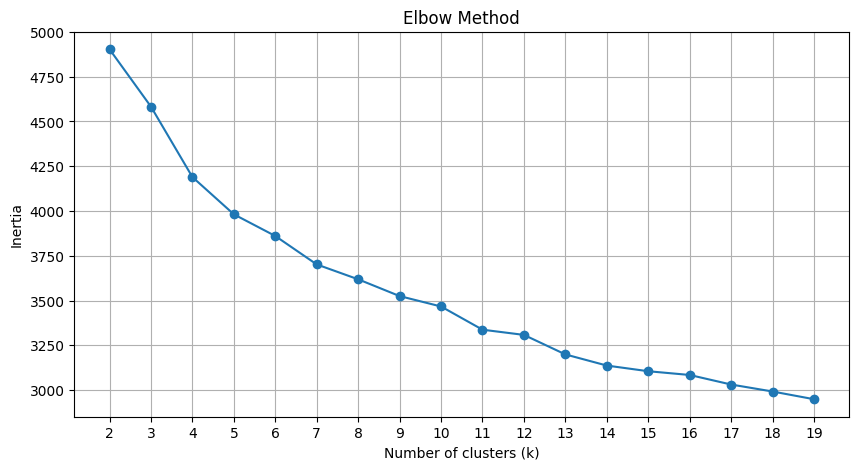

In [296]:
# running elbow method to find the optimal number of clusters
inertia_values = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_final)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.grid(True)
plt.show()

We think the optimal number of clusters would be either: 4, 6, 10 or 11

k=2: silhouette score = 0.1383
k=3: silhouette score = 0.1523
k=4: silhouette score = 0.1789
k=5: silhouette score = 0.1513
k=6: silhouette score = 0.1660
k=7: silhouette score = 0.1569
k=8: silhouette score = 0.1235
k=9: silhouette score = 0.1321
k=10: silhouette score = 0.1242
k=11: silhouette score = 0.1171
k=12: silhouette score = 0.1134
k=13: silhouette score = 0.1241
k=14: silhouette score = 0.1338
k=15: silhouette score = 0.1328
k=16: silhouette score = 0.1395
k=17: silhouette score = 0.1436
k=18: silhouette score = 0.1373
k=19: silhouette score = 0.1416


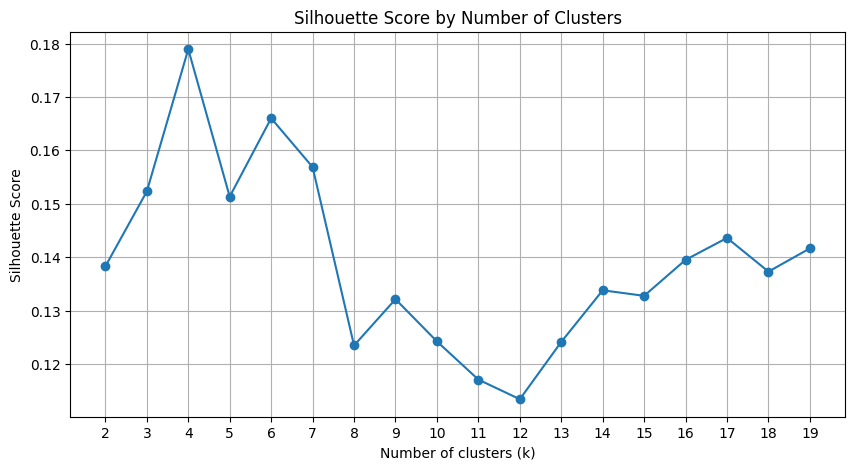

In [299]:
# running silhouette method to find the optimal number of clusters
silhouette_values = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_final)
    score = silhouette_score(X_final, labels)
    silhouette_values.append(score)
    print(f'k={k}: silhouette score = {score:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Making tests with k = 4 and k =6 and inspecting the genre buckets to take a decision

In [300]:
# Test k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
books['cluster_4'] = kmeans_4.fit_predict(X_final)

# Inspect k=4 clusters
for cluster in range(4):
    print(f'\n--- Cluster {cluster} (k=4) ---')
    sample = books[books['cluster_4'] == cluster][['title', 'genres']].head(5)
    print(sample.to_string())


--- Cluster 0 (k=4) ---
                                                                         title                                                                                      genres
book_id                                                                                                                                                                   
0                                      The Hunger Games (The Hunger Games, #1)                Young Adult, Dystopia, Fiction, Fantasy, Science Fiction, Romance, Adventure
3                 Harry Potter and the Order of the Phoenix (Harry Potter, #5)                    Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens
5                                                 Twilight (Twilight Saga, #1)            Fantasy, Young Adult, Romance, Fiction, Vampires, Paranormal, Paranormal Romance
7        J.R.R. Tolkien 4-Book Boxed Set: The Hobbit and The Lord of the Rings  Fantasy, Fiction, Classics, Adventure, S

In [301]:
# Test k=6
kmeans_6 = KMeans(n_clusters=6, random_state=42)
books['cluster_6'] = kmeans_6.fit_predict(X_final)

# Inspect k=6 clusters
for cluster in range(6):
    print(f'\n--- Cluster {cluster} (k=6) ---')
    sample = books[books['cluster_6'] == cluster][['title', 'genres']].head(5)
    print(sample.to_string())


--- Cluster 0 (k=6) ---
                                                                title                                                                         genres
book_id                                                                                                                                             
6                                                         Animal Farm             Classics, Fiction, Dystopia, Fantasy, School, Politics, Literature
10                                         The Picture of Dorian Gray          Classics, Fiction, Horror, Gothic, Fantasy, Literature, Dark Academia
13                                                    The Giving Tree      Childrens, Classics, Fiction, Picture Books, Poetry, Young Adult, Fantasy
19                                               Crime and Punishment  Classics, Fiction, Russia, Russian Literature, Literature, Philosophy, Novels
21       Alice’s Adventures in Wonderland / Through the Looking-Glass      Classi

We decided to use K = 6. We feel it is more granular than 4 and still very good bucketing of the books for recommendation

In [302]:
# running our decision on k = 6 clusters for the final model
kmeans_final = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_final)

In [303]:
# concatenating the cluster labels to the original dataframe
books['cluster'] = cluster_labels

In [304]:
# verifying all is good with the new column
print(books['cluster'].value_counts())
print('\nSample:')
print(books[['title', 'genres', 'cluster']].head(10))

cluster
1    926
4    298
5    216
2    206
0    182
3    176
Name: count, dtype: int64

Sample:
                                                     title  \
book_id                                                      
0                  The Hunger Games (The Hunger Games, #1)   
1                                      Pride and Prejudice   
2                                    To Kill a Mockingbird   
3        Harry Potter and the Order of the Phoenix (Har...   
4                                           The Book Thief   
5                             Twilight (Twilight Saga, #1)   
6                                              Animal Farm   
7        J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...   
8        The Chronicles of Narnia (The Chronicles of Na...   
9                                   The Fault in Our Stars   

                                                    genres  cluster  
book_id                                                              
0        Young Adu

In [305]:
books.head()

,title,author,avg_rating,num_ratings,cover_img_url,goodreads_url,source,year_published,genres,description,pages,series,isbn,publisher,language,ol_key,google_url,cluster_4,cluster_6,cluster
book_id,,,,,,,,,,,,,,,,,,,,
0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.35,10115839,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/2767052-th...,GoodReads,2008,"Young Adult, Dystopia, Fiction, Fantasy, Scien...",Winning means fame and fortune. Losing means c...,374,The Hunger Games#1,NaN,NaN,NaN,NaN,NaN,0,4,4
1,Pride and Prejudice,Jane Austen,4.30,4920467,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/1885.Pride...,GoodReads,1813,"Classics, Romance, Fiction, Historical Fiction...","Since its immediate success in 1813,Pride and ...",279,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
2,To Kill a Mockingbird,Harper Lee,4.26,7016855,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/2657.To_Ki...,GoodReads,1960,"Classics, Fiction, Historical Fiction, School,...","""Shoot all the bluejays you want, if you can h...",323,To Kill a Mockingbird#1,NaN,NaN,NaN,NaN,NaN,2,2,2
3,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling,4.50,3868435,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/58613451-h...,GoodReads,2003,"Fantasy, Fiction, Young Adult, Harry Potter, M...",It's official: the evil Lord Voldemort has ret...,896,Harry Potter#5,NaN,NaN,NaN,NaN,NaN,0,4,4
4,The Book Thief,Markus Zusak,4.39,2935583,https://i.gr-assets.com/images/S/compressed.ph...,https://www.goodreads.com/book/show/19063.The_...,GoodReads,2005,"Historical Fiction, Fiction, Young Adult, Clas...",Librarian's note: An alternate cover edition c...,592,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2


In [306]:
# dropping the test cluster columns
books = books.drop(columns=['cluster_4', 'cluster_6'])

In [311]:
# adding genre_list column to the original dataframe for standardize display of genres
# Add clean genres as a new column
def join_genres(genre_list):
    return ', '.join(genre_list)

books['genres_clean'] = books_model['genres_list'].apply(join_genres)

# Check result
books[['title', 'genres', 'genres_clean']].head(10)

,title,genres,genres_clean
book_id,,,
0,"The Hunger Games (The Hunger Games, #1)","Young Adult, Dystopia, Fiction, Fantasy, Scien...","Young Adult, Dystopia, Fiction, Fantasy, Scien..."
1,Pride and Prejudice,"Classics, Romance, Fiction, Historical Fiction...","Classics, Romance, Fiction, Historical Fiction..."
2,To Kill a Mockingbird,"Classics, Fiction, Historical Fiction, School,...","Classics, Fiction, Historical Fiction, Literat..."
3,Harry Potter and the Order of the Phoenix (Har...,"Fantasy, Fiction, Young Adult, Harry Potter, M...","Fantasy, Fiction, Young Adult, Fantasy, Childrens"
4,The Book Thief,"Historical Fiction, Fiction, Young Adult, Clas...","Historical Fiction, Fiction, Young Adult, Clas..."
5,"Twilight (Twilight Saga, #1)","Fantasy, Young Adult, Romance, Fiction, Vampir...","Fantasy, Young Adult, Romance, Fiction, Fantas..."
6,Animal Farm,"Classics, Fiction, Dystopia, Fantasy, School, ...","Classics, Fiction, Dystopia, Fantasy, Politics..."
7,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,"Fantasy, Fiction, Classics, Adventure, Science...","Fantasy, Fiction, Classics, Adventure, Science..."
8,The Chronicles of Narnia (The Chronicles of Na...,"Fantasy, Classics, Fiction, Young Adult, Child...","Fantasy, Classics, Fiction, Young Adult, Child..."


In [312]:
# checking columns to make sure the right ones were dropped
print(books.columns.tolist())

['title', 'author', 'avg_rating', 'num_ratings', 'cover_img_url', 'goodreads_url', 'source', 'year_published', 'genres', 'description', 'pages', 'series', 'isbn', 'publisher', 'language', 'ol_key', 'google_url', 'cluster', 'genres_clean']


In [313]:
# exporting the final dataframe with clusters
books.to_csv('../01. Data/books_with_clusters.csv', index=True)